# Submission 3 – Final Submission

## Instructions

- Fill out the *Basic Information* and the *Results* sections.
- Make sure that this `.ipynb` file displays correctly in the GitHub file preview, including any visual output.
- If you find that any output does not display correctly, include a static screenshot as an image. For interactive outputs, add a link to a short screencast located in your repository.
- Push all required files before the deadline.

---
## Basic Information

**Team Name:** powerpuff-girls

**Team Members:**
- Saba Zia Naserani
- Elmedin Zukic
- Egzona Gashi

**Dataset Description:**  
(max. 75 words; this serves just as a reminder)

This dataset contains metadata for 8,807 Netflix titles (movies and TV shows) available up to 2021, sourced from Kaggle. It includes 12 attributes: title, type, director, cast, country, date added, release year, rating, duration, and genre. It supports analysis of content distribution, temporal trends, and regional differences across Netflix’s global catalog.

---

## Code

Here you may place any code that is not an immediate part of your submission. Only the content of the *Results* sections will be graded for this submission.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load data ───────────────────────────────────────────────────────────────
df = pd.read_csv('../data/netflix_titles.csv')

# ── Genre mapping: collapse type-specific labels into unified categories ─────
GENRE_MAP = {
    'Dramas': 'Drama',
    'TV Dramas': 'Drama',
    'Comedies': 'Comedy',
    'TV Comedies': 'Comedy',
    'Action & Adventure': 'Action & Adventure',
    'TV Action & Adventure': 'Action & Adventure',
    'International Movies': 'International',
    'International TV Shows': 'International',
    'Documentaries': 'Documentary',
    'Docuseries': 'Documentary',
    'Children & Family Movies': 'Kids & Family',
    "Kids' TV": 'Kids & Family',
    'Horror Movies': 'Horror',
    'TV Horror': 'Horror',
    'Thrillers': 'Thriller',
    'TV Thrillers': 'Thriller',
    'Sci-Fi & Fantasy': 'Sci-Fi & Fantasy',
    'TV Sci-Fi & Fantasy': 'Sci-Fi & Fantasy',
    'Romantic Movies': 'Romance',
    'Romantic TV Shows': 'Romance',
    'Crime TV Shows': 'Crime',
    'Independent Movies': 'Independent',
    'Anime Features': 'Anime',
    'Anime Series': 'Anime',
    'Reality TV': 'Reality TV',
    'Stand-Up Comedy': 'Stand-Up Comedy',
    'Stand-Up Comedy & Talk Shows': 'Stand-Up Comedy',
    'Music & Musicals': 'Music & Musicals',
    'Sports Movies': 'Sports',
    'Science & Nature TV': 'Science & Nature',
    'British TV Shows': 'British TV',
    'Korean TV Shows': 'Korean TV',
    'Spanish-Language TV Shows': 'Spanish-Language TV',
    'Classic Movies': 'Classic',
    'Classic & Cult TV': 'Classic',
    'Cult Movies': 'Cult Movies',
    'LGBTQ Movies': 'LGBTQ',
    'Faith & Spirituality': 'Faith & Spirituality',
    'Movies': 'Other',
    'TV Shows': 'Other',
}

df_g = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
df_g['genre_clean'] = df_g['genre'].map(GENRE_MAP).fillna(df_g['genre'])

# ── Date / country preprocessing ─────────────────────────────────────────────
df_dated = df.dropna(subset=['date_added', 'country']).copy()
df_dated['primary_country'] = df_dated['country'].str.split(', ').str[0]
df_dated['year_added'] = pd.to_datetime(
    df_dated['date_added'].str.strip(), format='mixed'
).dt.year

print('Data loaded successfully')
print(f'Total rows: {len(df)}')

Data loaded successfully
Total rows: 8807


---
## Results – Complex Hypotheses/Tasks

### B.1

Restate your hypothesis/task below.

**Hypothesis B.1:** Movies and TV shows differ in the genres they belong to, with certain genres being more dominant in one type of content. Genre-specific storytelling formats, audience expectations, and production strategies across the two content types drive these differences.

Place your visualizations below (max. 2). Make sure that everything displays correctly in the GitHub file preview.

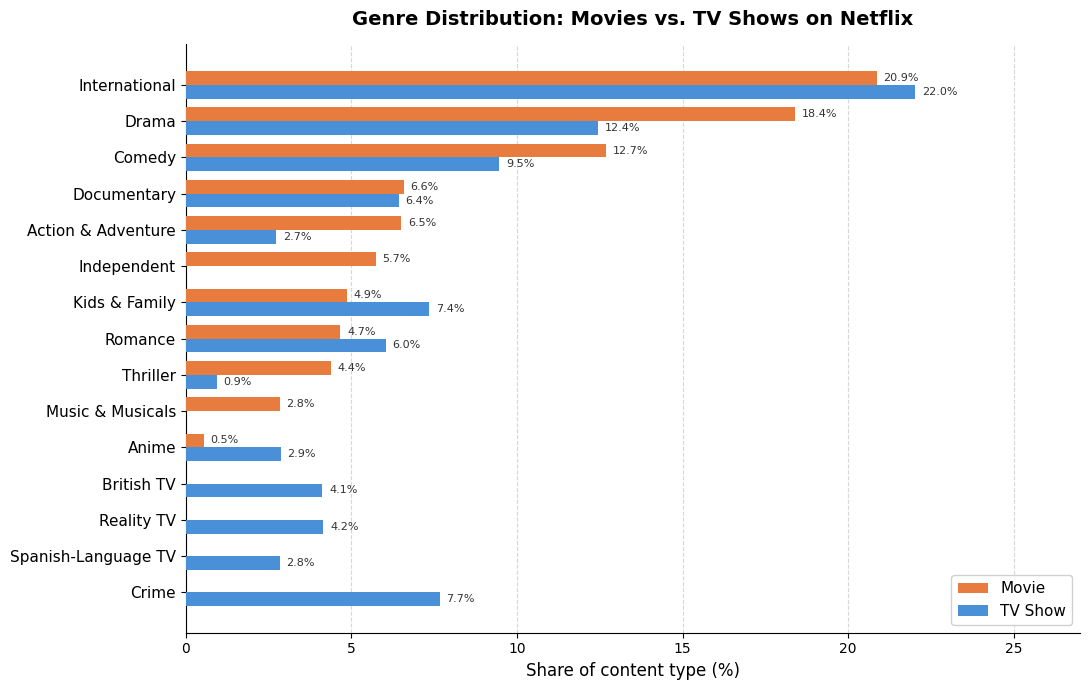

In [2]:
# ── B.1: Grouped Horizontal Bar Chart – Genre Distribution by Content Type ──

# Compute genre share (%) within each content type
counts = df_g.groupby(['type', 'genre_clean']).size().unstack(fill_value=0).T
counts.columns = ['Movie', 'TV Show']
counts['movie_pct'] = counts['Movie'] / counts['Movie'].sum() * 100
counts['tv_pct']    = counts['TV Show'] / counts['TV Show'].sum() * 100
counts['max_pct']   = counts[['movie_pct', 'tv_pct']].max(axis=1)

# Keep top 15 genres by their peak share in either type
top15 = (
    counts[counts['max_pct'] > 0]
    .nlargest(15, 'max_pct')
    .sort_values('movie_pct')
)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

MOVIE_COLOR = '#E87B3E'
TV_COLOR    = '#4A90D9'

y_pos  = np.arange(len(top15))
bar_h  = 0.38

bars_m = ax.barh(y_pos + bar_h / 2, top15['movie_pct'], height=bar_h,
                 color=MOVIE_COLOR, label='Movie', zorder=3)
bars_t = ax.barh(y_pos - bar_h / 2, top15['tv_pct'],   height=bar_h,
                 color=TV_COLOR,   label='TV Show', zorder=3)

for bar in bars_m:
    w = bar.get_width()
    if w > 0.5:
        ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{w:.1f}%', va='center', fontsize=8, color='#333333')

for bar in bars_t:
    w = bar.get_width()
    if w > 0.5:
        ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{w:.1f}%', va='center', fontsize=8, color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(top15.index, fontsize=11)
ax.set_xlabel('Share of content type (%)', fontsize=12)
ax.set_title('Genre Distribution: Movies vs. TV Shows on Netflix',
             fontsize=14, fontweight='bold', pad=14)
ax.legend(fontsize=11, framealpha=0.9)
ax.set_xlim(0, 27)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task.
Use no more than 150 words and indicate the word count of your description below.

**Description:**
The grouped horizontal bar chart compares the percentage share of each genre within Movies (orange) and TV Shows (blue), normalised independently so shares reflect internal composition rather than raw counts.

The chart strongly supports the hypothesis. International content, Drama, and Comedy dominate both types, but with clear differences: Drama accounts for 18.4% of Movies versus 12.4% of TV Shows. Genre categories exclusive to one medium — Crime (7.7% TV only), Independent (5.7% Movie only), and Stand-Up Comedy (2.6% Movie only) — confirm that storytelling format shapes genre composition. Horror and Thriller lean toward Movies, whereas Reality TV and Crime skew toward TV Shows. The side-by-side layout makes these asymmetries immediately visible, confirming that content type is a strong predictor of genre.

**Word count:** 121

### B.2

Restate your hypothesis/task below.

**Hypothesis B.2:** The type of content available on Netflix depends on both the country of origin and the year it was added. Cultural differences between regions and changes in global trends over time influence what kind of content — Movies or TV Shows — is produced and made available on the platform.

Place your visualizations below (max. 2). Make sure that everything displays correctly in the GitHub file preview.

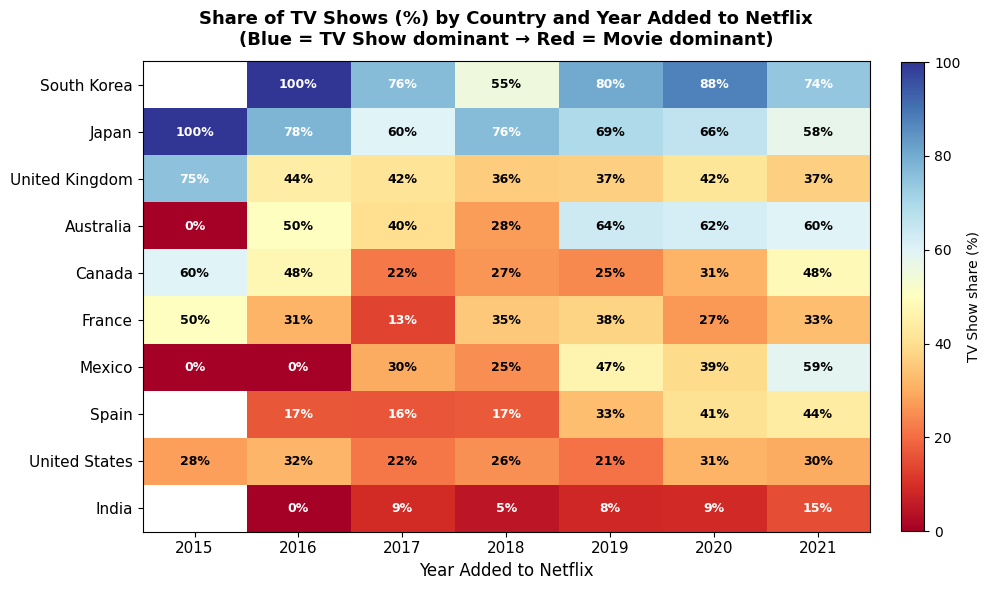

In [3]:
# ── B.2: Heatmap – TV Show Share (%) per Country per Year ───────────────────

top10_countries = df_dated['primary_country'].value_counts().head(10).index.tolist()

df_top = df_dated[
    df_dated['primary_country'].isin(top10_countries) &
    df_dated['year_added'].between(2015, 2021)
].copy()

pivot = (
    df_top
    .groupby(['primary_country', 'year_added', 'type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Movie', 'TV Show'], fill_value=0)
)
pivot['total']    = pivot.sum(axis=1)
pivot['tv_share'] = pivot['TV Show'] / pivot['total'] * 100

heatmap_data = pivot['tv_share'].unstack('year_added')
# Order countries by mean TV Show share (descending)
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values(ascending=False).index
]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap_data.values, cmap='RdYlBu',
               aspect='auto', vmin=0, vmax=100)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        if not np.isnan(val):
            text_color = 'white' if (val > 70 or val < 20) else 'black'
            ax.text(j, i, f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='bold')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns.astype(int), fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=11)
ax.set_xlabel('Year Added to Netflix', fontsize=12)
ax.set_title(
    'Share of TV Shows (%) by Country and Year Added to Netflix\n'
    '(Blue = TV Show dominant \u2192 Red = Movie dominant)',
    fontsize=13, fontweight='bold', pad=12
)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('TV Show share (%)', fontsize=10)

plt.tight_layout()
plt.show()

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task. Use no more than 150 words and indicate the word count of your description below.

**Description:**
The heatmap shows the percentage of TV Shows (vs. Movies) added to Netflix for the top 10 content-producing countries between 2015 and 2021. Blue cells indicate TV Show dominance; red indicates Movie dominance.

The hypothesis is strongly supported on both dimensions. South Korea and Japan are consistently TV Show-heavy (74–100% TV Shows), reflecting strong serial drama cultures. India and the United States are Movie-dominant across all years (below 32%), driven by large film industries. France and Canada show a moderate, mixed split. Temporally, most countries show increasing TV Show shares from 2019 onwards, suggesting a platform-wide shift toward episodic content. The combined country-and-year view reveals that both cultural origin and time period jointly determine content type, confirming the hypothesis.

**Word count:** 124

---

## Results – Black-Hat Visualization

Place your black hat visualization below. Make sure that everything displays correctly in the GitHub file preview.

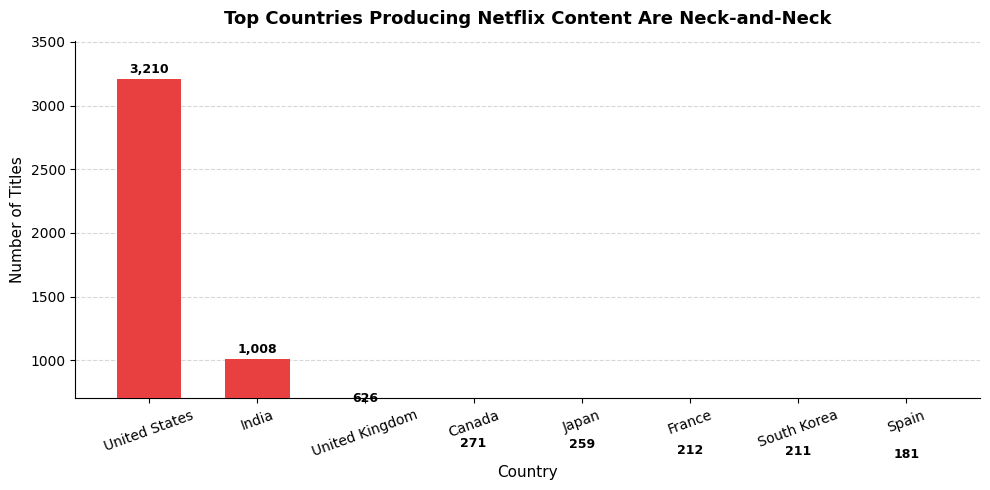

In [4]:
# ── Black-Hat: Truncated Y-axis Bar Chart ────────────────────────────────────
# Deception: the y-axis starts at 700 instead of 0, making countries appear
# almost equal in content count when the US actually has 3x more than India.

df_c = df.dropna(subset=['country']).copy()
df_c['primary_country'] = df_c['country'].str.split(', ').str[0]
top8 = df_c['primary_country'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(top8.index, top8.values, color='#E84040', width=0.6, zorder=3)

# THE DECEPTION: y-axis does NOT start at 0
ax.set_ylim(700, top8.max() + 300)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f'{bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title(
    'Top Countries Producing Netflix Content Are Neck-and-Neck',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_ylabel('Number of Titles', fontsize=11)
ax.set_xlabel('Country', fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Describe your black-hat visualization. What was your motivation? How did you achieve the desired effect? Use no more than 150 words and indicate the word count of your description below.

**Description:**
The bar chart displays Netflix title counts by country but uses a truncated y-axis starting at 700 instead of 0, accompanied by the misleading title “neck-and-neck.” In reality, the United States has 3,210 titles — more than three times India’s 1,008 — yet the bars appear nearly equal in height.

The deception exploits a fundamental perceptual principle: viewers judge bar magnitude by height. Cutting the baseline drastically exaggerates small differences and conceals large ones. A media outlet or political actor could use this to falsely imply that the US holds no significant production lead. The fix is trivial — starting the y-axis at 0 restores the true 3:1 ratio — yet the truncated version is visually convincing enough to mislead a casual reader.

**Word count:** 139